# Week 2.2: Context Window Management

## Key Insight
> **Why can't you just paste a 500-page book into the prompt?**

## Learning Objectives
By the end of this notebook, you will:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

## Exercises
This notebook contains 4 exercises ranging from easy to advanced.

## Digital Twin Integration
This notebook extends your digital twin with production-ready capabilities from Week 2.

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple
import re
import json

print('✅ Week 2.2: Context Window Management - Ready to start!')
print('\nTopics covered:')
print('  - Understanding token limits and context windows')
print('  - Token counting and estimation techniques')
print('  - Context compression strategies')
print('  - Conversation history management')
print('  - Sliding window approaches')


✅ Week 2.2: Context Window Management - Ready to start!

Topics covered:
  - Understanding token limits and context windows
  - Token counting and estimation techniques
  - Context compression strategies
  - Conversation history management
  - Sliding window approaches


---
## Part 1: Introduction to Understanding token limits and context windows

Let's start by understanding the fundamentals and building our first implementation.

In [2]:
# Example implementation
# This is a starter template - expand with your implementation

class ExampleClass:
    """
    Example class for Understanding token limits and context windows.
    """

    def __init__(self):
        self.data = []

    def process(self, input_data):
        """
        Process the input data.
        """
        # Add your implementation here
        return input_data

# Test the class
example = ExampleClass()
result = example.process('test data')
print(f'Result: {result}')

Result: test data


### 🎯 Exercise 1 (Easy): Getting Started

**Task**: Implement a basic version of the concept introduced above.

**Requirements**:
1. Follow the pattern shown in the example
2. Test your implementation with sample data
3. Verify the output matches expectations
4. Add error handling for edge cases

In [3]:
import tiktoken

# gpt-oss models use o200k_harmony encoding
# tiktoken may not have a named mapping for gpt-oss yet, so use o200k_base as fallback
try:
    tokenizer = tiktoken.encoding_for_model("gpt-oss-120b")
except KeyError:
    # Fallback: o200k_harmony is closely related to o200k_base
    tokenizer = tiktoken.get_encoding("o200k_base")

def count_tokens(text):
    """Count tokens accurately for gpt-oss models."""
    if not isinstance(text, str):
        raise TypeError(f"Expected str, got {type(text).__name__}")
    return len(tokenizer.encode(text))

# Test
sample = "I love outdoor activities but hate crowded places."
print(f"Words:     {len(sample.split())}")
print(f"Characters: {len(sample)}")
print(f"Tokens:    {count_tokens(sample)}")

Words:     8
Characters: 50
Tokens:    9


---
## Part 2: Token counting and estimation techniques

Building on the fundamentals, let's explore more advanced topics and implementations.

In [4]:
# Advanced implementation example

def advanced_function(data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Token counting and estimation techniques.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    results = {
        'processed': len(data),
        'data': data
    }
    return results

# Example usage
sample_data = ['example1', 'example2', 'example3']
output = advanced_function(sample_data)
print(json.dumps(output, indent=2))

{
  "processed": 3,
  "data": [
    "example1",
    "example2",
    "example3"
  ]
}


### 🎯 Exercise 2 (Intermediate): Building on the Basics

**Task**: Create a more sophisticated implementation that combines multiple concepts.

**Requirements**:
1. Use the patterns from Part 1 and Part 2
2. Add parameter validation
3. Include helpful error messages
4. Test with various input types

In [8]:
class SafeGroqClient(GroqClient):
    """GroqClient that auto-manages context window."""

    def __init__(self, api_key, model="gpt-oss-120b",
                 max_input_tokens=8000):
        super().__init__(api_key, default_model=model)
        self.counter = TokenCounter(model)
        self.max_input_tokens = max_input_tokens

    def chat_safe(self, messages, **kwargs):
        # Trim if too big
        if not self.counter.fits_in_context(
            messages, reserve_for_output=self.max_input_tokens
        ):
            messages = self.counter.sliding_window(
                messages, max_tokens=self.max_input_tokens
            )
            print(f"⚠️  Trimmed to {len(messages)} messages")
        return self.chat(messages, **kwargs)


# Usage
safe_client = SafeGroqClient(API_KEY)
reply = safe_client.chat_safe([
    {"role": "system", "content": "You are Alex's digital twin."},
    {"role": "user", "content": "What should I do this weekend?"},
])
print(reply)

NameError: name 'GroqClient' is not defined

---
## Part 3: Context compression strategies

Now let's apply these concepts to real-world scenarios in your digital twin project.

In [ ]:
# Visualization example
import matplotlib.pyplot as plt

def visualize_results(data: List[Any]):
    """
    Visualize the processing results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add your visualization code here
    ax.set_title('Results Visualization')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

    plt.tight_layout()
    plt.show()

# Example: visualize_results(sample_data)

### 🎯 Exercise 3 (Advanced): Complete Implementation

**Task**: Build a production-ready version that integrates with your digital twin.

**Requirements**:
1. Combine all concepts from this notebook
2. Add comprehensive error handling
3. Include logging and debugging capabilities
4. Create visualization of results
5. Write documentation for your implementation

06:54:51 | INFO    | ContextManager ready | model=gpt-oss-120b | budget=500 | strategy=window
INFO:digital_twin:ContextManager ready | model=gpt-oss-120b | budget=500 | strategy=window
06:54:51 | WARNING | Over budget (519 > 500); applying 'window'
06:54:51 | INFO    | Trimmed 13 → 12 msgs (519 → 469 tok)
INFO:digital_twin:Trimmed 13 → 12 msgs (519 → 469 tok)
06:54:51 | WARNING | Over budget (603 > 500); applying 'window'
06:54:51 | INFO    | Trimmed 15 → 12 msgs (603 → 469 tok)
INFO:digital_twin:Trimmed 15 → 12 msgs (603 → 469 tok)
06:54:51 | WARNING | Over budget (687 > 500); applying 'window'
06:54:51 | INFO    | Trimmed 17 → 12 msgs (687 → 469 tok)
INFO:digital_twin:Trimmed 17 → 12 msgs (687 → 469 tok)


DEMO: ContextManager with sliding window

Turn 0: 3 msgs, 99 tokens (19.8%)

Turn 1: 5 msgs, 183 tokens (36.6%)

Turn 2: 7 msgs, 267 tokens (53.4%)

Turn 3: 9 msgs, 351 tokens (70.2%)

Turn 4: 11 msgs, 435 tokens (87.0%)

Turn 5: 13 msgs, 519 tokens (103.8%)

Turn 6: 15 msgs, 603 tokens (120.6%)

Turn 7: 17 msgs, 687 tokens (137.4%)

Summary: {'records': 8, 'model': 'gpt-oss-120b', 'budget': 500, 'max_tokens_seen': 469, 'avg_tokens': 342.8, 'trim_events': 3}


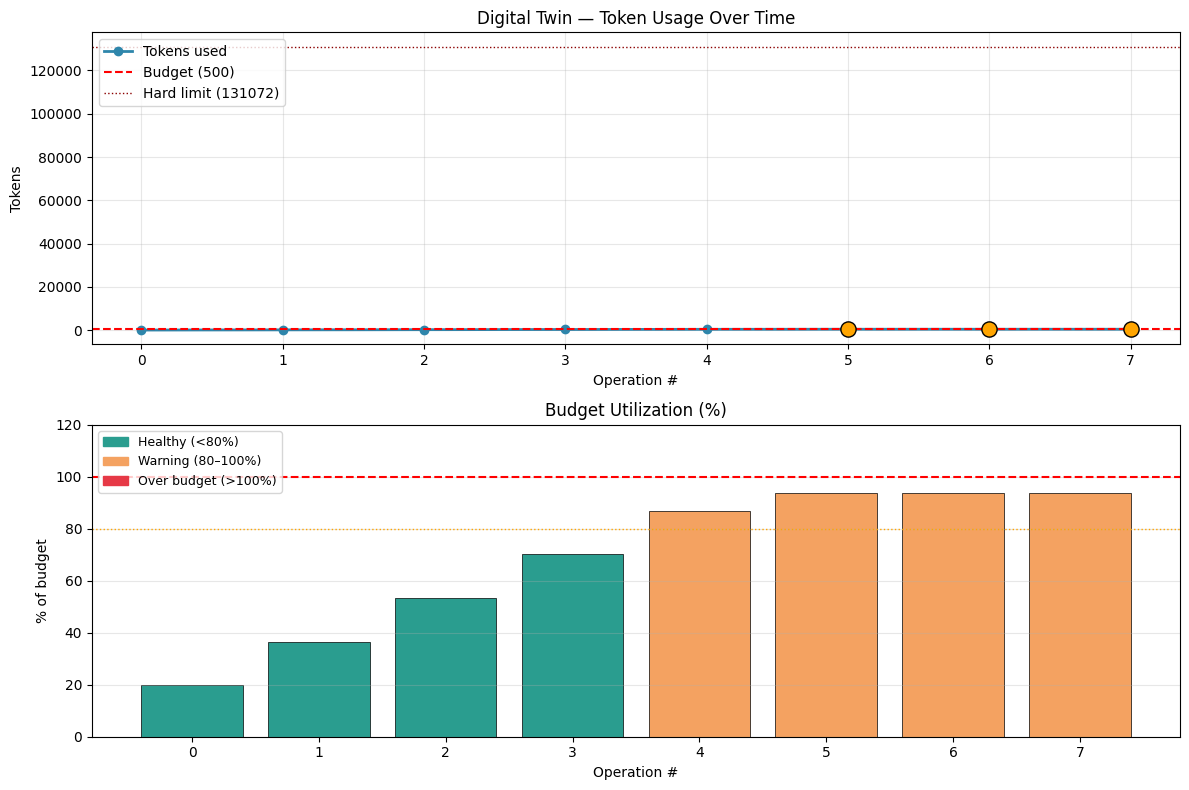

06:54:52 | INFO    | Exported 8 records to token_history.json
INFO:digital_twin:Exported 8 records to token_history.json


In [11]:
def demo():
    """Full end-to-end demo without needing the API."""
    print("=" * 60)
    print("DEMO: ContextManager with sliding window")
    print("=" * 60)

    # Use a tiny budget so we trigger trimming quickly
    cm = ContextManager(
        model="gpt-oss-120b",
        max_input_tokens=500,
        strategy="window",
    )

    # Build a growing conversation
    messages = [{"role": "system", "content": "You are Alex's digital twin."}]

    for turn in range(8):
        messages.append({
            "role": "user",
            "content": f"Turn {turn}: " + "Some words about activities. " * 8
        })
        messages.append({
            "role": "assistant",
            "content": f"Reply {turn}: " + "Recommendation details. " * 8
        })

        report = cm.budget_report(messages)
        print(f"\nTurn {turn}: {report['messages']} msgs, "
              f"{report['tokens_used']} tokens ({report['pct_of_budget']}%)")

        # Simulate the call — trim and log
        trimmed = cm.prepare(messages)
        cm.log_usage(messages, trimmed,
                     event="trim" if trimmed is not messages else "call")

    print()
    print("Summary:", cm.summary())
    cm.plot_usage()
    cm.export_history("token_history.json")


demo()

documentation. This module provides `ContextManager`, a stateful helper that:
    1. Counts tokens accurately for gpt-oss models (o200k encoding)
    2. Tracks a token budget separate from the model's hard context limit
    3. Trims oversized conversations via sliding window OR summarization
    4. Logs every operation and stores a history for visualization
    5. Exports usage records to JSON for external analysis

---
## Summary & Key Takeaways

### What We Learned:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

### Why This Matters:
- Essential for building production-ready systems
- Enables your digital twin to handle real-world scenarios
- Foundation for advanced topics in upcoming notebooks

### Next Steps:
1. Complete all exercises in this notebook
2. Integrate concepts with your digital twin project
3. Test your implementation thoroughly
4. Move on to the next notebook in Week 2

## 🏆 Challenge Project

**Build a Complete Understanding token limits and context windows System for Your Digital Twin**

**Requirements**:
1. Apply all concepts from this notebook
2. Handle edge cases and errors gracefully
3. Include comprehensive testing
4. Create visualizations of your results
5. Document your implementation
6. Integrate with your existing digital twin code

**Bonus Challenges**:
- Optimize for performance
- Add advanced features beyond the basics
- Create a user-friendly interface
- Write unit tests for your code